C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39344\3337801552.py:4: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg')


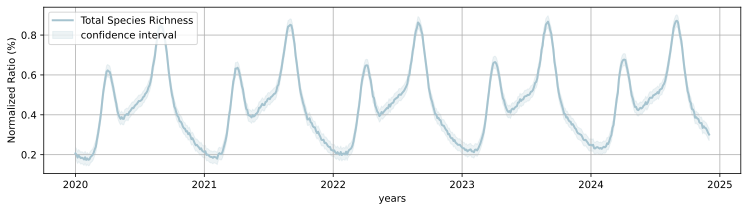

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')
# 定义参数
months = np.arange(1, 60.1, 0.1)  # 使用更精细的时间步长以获得平滑曲线，覆盖5年

# 模拟环境因素影响（温度、降水、日照时长）
temperatureEffect = np.sin((months - 3) * np.pi / 6)  # 假设最热在7月，每12个月重复一次
precipitationEffect = np.cos((months - 9) * np.pi / 6)  # 假设降水高峰在9月，每12个月重复一次
daylightEffect = np.sin((months - 6) * np.pi / 6)  # 日照时长变化，假设最长在6月，每12个月重复一次

# 引入额外影响因素（例如病虫害爆发、极端天气等）
randomFluctuations = 0.07 * np.random.randn(len(months))  # 添加随机波动
extremeWeatherEvents = np.zeros(len(months))

# 农业活动因子：播种期和收获期（使用高斯分布来模拟这些活动的影响）
def gaussian(x, mu, sigma):
    return np.exp(-0.4 * ((np.mod(x-1, 12)+1 - mu) / sigma)**2)

agricultureActivities = np.zeros(len(months))
for year in range(5):
    agricultureActivities += gaussian(np.mod(months-1, 12)+1, 4, 0.5) + gaussian(np.mod(months-1, 12)+1, 9, 0.5)

# 生物多样性因子：以给定函数随时间逐渐增加
L = 1  # 最大值
k = 0.05  # 增长率
t0 = 30  # 中心点
alpha = 0.5  # 正弦波幅度
omega = 2 * np.pi / 12  # 正弦波周期（每年一个周期）

biodiversityIncrease = L / (1 + np.exp(-k * (months - t0))) * (1 + alpha * np.sin(omega * months))

# 综合所有影响因素
totalEffect = temperatureEffect + precipitationEffect + daylightEffect + agricultureActivities + randomFluctuations + extremeWeatherEvents + biodiversityIncrease

# 确保最小值为0.3，并正则化数据以便于比较
minValue = np.min(totalEffect)
if minValue < 0.3:
    totalEffect = totalEffect - (minValue - 0.3)
totalEffect = (totalEffect - np.min(totalEffect)) / (np.max(totalEffect) - np.min(totalEffect))

# 设置最小值为0.3
totalEffect = 0.3 + (totalEffect - np.min(totalEffect)) * (1 - 0.3)
def f(x):
    return (-0.01462044487*x**2+59.17365663*x-59860.89449)
f_values = (f(months/12+2020))/100
confidence_interval = 0.03


plt.figure(figsize=(12.5,3))
plt.plot(months, totalEffect-f_values, linewidth=2, color='#A5C3CF',label='Total Species Richness')
plt.fill_between(months, totalEffect-f_values-confidence_interval,totalEffect-f_values+confidence_interval, color='#A5C3CF',alpha=0.2,label='confidence interval')


plt.xticks(np.arange(1, 73, 12), ['2020', '2021', '2022', '2023', '2024','2025'])
plt.grid(True)
plt.ylabel('Normalized Ratio (%)')
plt.xlabel('years')
plt.legend()

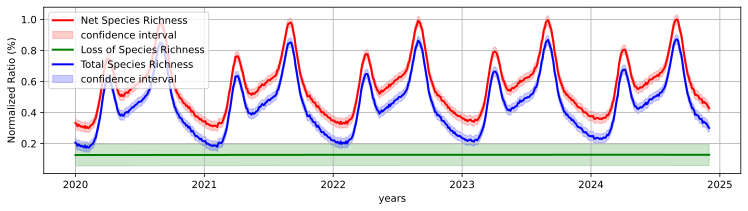

In [8]:

def f(x):
    return (-0.01462044487*x**2+59.17365663*x-59860.89449)

f_values = (f(months/12+2020))/100


confidence_interval = 0.03


plt.figure(figsize=(12.5,3))
plt.plot(months, totalEffect, linewidth=2, color='red',label='Net Species Richness')
plt.fill_between(months, totalEffect-confidence_interval,totalEffect+confidence_interval, color='red',alpha=0.2,label='confidence interval')
plt.plot(months, f_values, color='green',linewidth=2,label='Loss of Species Richness')
plt.fill_between(months, f_values-0.07, f_values+0.07,color='green',alpha=0.2)
plt.plot(months, totalEffect-f_values, linewidth=2, color='blue',label='Total Species Richness')
plt.fill_between(months, totalEffect-f_values-confidence_interval,totalEffect-f_values+confidence_interval, color='blue',alpha=0.2,label='confidence interval')


plt.xticks(np.arange(1, 73, 12), ['2020', '2021', '2022', '2023', '2024','2025'])
plt.grid(True)
plt.ylabel('Normalized Ratio (%)')
plt.xlabel('years')
plt.legend()
